## 0. Preparación (solo en Google Colab)

Esta celda no hace nada en local. En Colab clona el repositorio, entra en él y comprueba las librerías: solo instala las que falten o sean demasiado viejas (sobre todo `scikit-learn` 1.9, la versión con la que la app carga el modelo guardado). Lo normal es que corra a la primera, sin reiniciar.

Solo si `pip` tuviera que actualizar una librería que Colab ya tiene cargada, el entorno se reinicia solo: vuelve a ejecutar desde esta celda y sigue.

In [ ]:
import os
import re
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

if "google.colab" in sys.modules:
    REPO_DIR = Path("/content/Chefwise")
    if not REPO_DIR.exists():
        subprocess.check_call(["git", "clone", "-q", "https://github.com/lezti02/Chefwise.git", str(REPO_DIR)])
    os.chdir(REPO_DIR)

    # Versiones mínimas. Solo se instala lo que falte o sea más viejo, para no tocar lo que Colab ya trae.
    # scikit-learn 1.9 es la que importa: es la versión con la que la app carga el modelo guardado.
    MIN_VERSIONS = {"pandas": "2.2", "numpy": "2.0", "scipy": "1.12", "scikit-learn": "1.9", "joblib": "1.4"}

    def as_tuple(v):
        return tuple(int(x) for x in re.findall(r"\d+", v)[:3])

    def satisfied(name, minimum):
        try:
            return as_tuple(version(name)) >= as_tuple(minimum)
        except PackageNotFoundError:
            return False

    missing = [f"{name}>={minimum}" for name, minimum in MIN_VERSIONS.items() if not satisfied(name, minimum)]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    # Solo si pip cambió una librería que Colab ya tenía cargada hay que reiniciar (caso poco común).
    loaded = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy", "sklearn": "scikit-learn"}
    stale = [m for m, dist in loaded.items() if m in sys.modules and sys.modules[m].__version__ != version(dist)]
    if stale:
        print(f"Se actualizaron {stale}: el entorno se reinicia solo. Cuando termine, ejecuta de nuevo desde esta celda.")
        os.kill(os.getpid(), 9)

# 06. Clusterización con K-Means

Este notebook agrupa las recetas de `data/processed/recetas_modelo.csv` (el que dejó el notebook 02) en grupos de recetas parecidas.

**La idea en una frase:** K-Means parte las recetas en `k` grupos. Cada receta se va al grupo cuyo centro le queda más cerca.

```text
recetas_modelo.csv  ->  columnas numéricas  ->  misma escala  ->  probar varios k  ->  quedarse con uno  ->  perfil de cada grupo
```

No es el recomendador (eso está en los notebooks 03, 04 y 05). Aquí no comparamos una receta contra otra para sugerirla: solo preguntamos si el catálogo se parte en grupos reconocibles.

K-Means no sabe cómo se llaman los grupos. El número de cada grupo (0, 1, 2...) es una etiqueta arbitraria: el grupo 0 no es "mejor" que el grupo 1.

### Qué hace cada sección

| # | Sección | Qué queda hecho |
| --- | --- | --- |
| 1 | Librerías y ruta | El CSV se puede leer desde la raíz del proyecto o desde `notebooks/` |
| 2 | Lectura y revisión | Una fila por receta, sin `recipe_id` repetido |
| 3 | Qué columnas entran | Solo números que describen la receta, sin contar dos veces lo mismo |
| 4 | Escala | Conteos y minutos en logaritmo, y después todo en la misma escala |
| 5 | Varios `k` | Inercia, silueta, Calinski-Harabasz y Davies-Bouldin |
| 6 | Modelo final | El `k` de mayor silueta (se puede cambiar a mano) |
| 7 | Material para interpretar | Tamaños, perfil y recetas cercanas al centro |
| 8 | Interpretación | Vacía a propósito |

La sección 8 no se redacta aquí.


## 1. Librerías y ruta

* `pandas` lee la tabla.
* `numpy` hace las cuentas.
* `scikit-learn` ajusta K-Means y calcula las métricas.
* `matplotlib` dibuja las gráficas.

La semilla `42` deja el resultado repetible: el mismo CSV produce los mismos grupos.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 70)

# Si Jupyter arrancó dentro de notebooks/, la raíz es la carpeta de arriba.
cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "data" / "processed").exists() else cwd.parent
sys.path.insert(0, str(ROOT))

DATA_PATH = ROOT / "data" / "processed" / "recetas_modelo.csv"

# Semilla única: K-Means, la muestra de la silueta y cualquier sorteo usan esta.
RANDOM_STATE = 42
# k que se prueban. Con k=1 no existe "separación entre grupos", así que se empieza en 2.
K_MIN, K_MAX = 2, 15
# La silueta compara cada receta con las demás. Con ~29 mil filas eso es muy lento,
# así que se estima en una muestra. 4,000 alcanza para que el número no baile.
SILHOUETTE_SAMPLE = 4_000
# Cuántas veces se arranca K-Means por cada k. Se queda con el arranque de menor inercia:
# un solo arranque puede caer en un agrupamiento malo.
N_INIT = 10

# Colores de las gráficas, los mismos del resto de los notebooks.
OLIVE, MUSTARD = "#5d7926", "#e8bd59"
INK, INK_SOFT, LINE = "#2F2E24", "#6b6a5c", "#e6e2d6"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": LINE,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "axes.grid": True,
    "grid.color": LINE,
    "grid.linewidth": 0.7,
    "axes.axisbelow": True,
})

print("Raíz del proyecto:", ROOT)
print("Dataset          :", DATA_PATH.relative_to(ROOT), "->", "existe" if DATA_PATH.exists() else "NO EXISTE (corre antes el notebook 02)")


Raíz del proyecto: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise
Dataset          : data/processed/recetas_modelo.csv -> existe


## 2. Lectura y revisión

Una fila es una receta. Antes de agrupar se comprueba que el archivo traiga las columnas que este notebook usa y que `recipe_id` no esté repetido. Si algo falla, la celda se detiene.


In [2]:
df = pd.read_csv(DATA_PATH)

# Conteos y tiempo. effort_score no entra: es una mezcla de ingredientes y pasos (se contaría dos veces).
COUNT_COLS = ["n_ingredients", "n_steps", "time_filled_min"]
# Técnicas de cocina, ya en 0/1.
FLAG_COLS = ["is_spicy", "needs_oven", "needs_frying", "needs_blender"]
# Una columna 0/1 por etiqueta de la app, en el orden del CSV.
TAG_COLS = [columna for columna in df.columns if columna.startswith("tag_")]
# La dificultad original tiene vacíos (~21 %). No se inventa un 1, 2 o 3: "desconocido" es una categoría más.
DIFFICULTY_LEVELS = ["facil", "intermedio", "reto", "desconocido"]

necesarias = ["recipe_id", "name", "tags", "difficulty", *COUNT_COLS, *FLAG_COLS, *TAG_COLS]
faltan = [columna for columna in necesarias if columna not in df.columns]
assert not faltan, f"Faltan columnas: {faltan}"
assert df["recipe_id"].is_unique, "hay recipe_id repetidos"
assert df[COUNT_COLS + FLAG_COLS + TAG_COLS].notna().all().all(), "hay vacíos en las columnas numéricas"

print(f"Recetas: {len(df):,} | columnas en el CSV: {df.shape[1]}")
print(f"Etiquetas 0/1 que entran: {len(TAG_COLS)}")
print(f"Dificultad vacía: {df['difficulty'].isna().mean():.1%} (pasa a 'desconocido', no se rellena con un número)")


Recetas: 28,798 | columnas en el CSV: 43
Etiquetas 0/1 que entran: 16
Dificultad vacía: 21.0% (pasa a 'desconocido', no se rellena con un número)


## 3. Qué columnas entran al agrupamiento

K-Means mide distancia entre filas. Solo entiende números, y cada columna jala esa distancia. Por eso no entra todo el CSV.

| Entra | Por qué |
| --- | --- |
| `n_ingredients`, `n_steps` | Tamaño de la receta |
| `time_filled_min` | Minutos. Si la fuente no traía tiempo, el notebook 02 ya dejó un estimado. `total_time_min` tiene vacíos y no se puede usar así |
| `tag_*` | Tipo de plato y proteína, en 0/1 |
| `is_spicy`, `needs_oven`, `needs_frying`, `needs_blender` | Técnica, en 0/1 |
| Dificultad en cuatro columnas 0/1 (`facil`, `intermedio`, `reto`, `desconocido`) | El vacío se queda visible. No se reemplaza por la dificultad promedio |

| No entra | Por qué |
| --- | --- |
| `recipe_id`, `recipe_key`, `name`, `url`, `source` | Identifican la receta o la página. No describen el plato |
| `recipe_text`, `ingredients_core` | Son texto. K-Means no lee palabras. El parecido por texto ya está en los notebooks 03 a 05 |
| `effort_score` | Sale de ingredientes y pasos. Meterlo junto con esos dos cuenta el mismo dato dos veces |
| `n_tags`, `has_meal_tag` | `n_tags` es la suma de las `tag_*`. `has_meal_tag` es un "o" de desayuno, comida, cena, postre y bebida |
| `is_quick`, `time_bucket` | Son cortes del mismo tiempo que ya entra como minutos |
| `difficulty` y `difficulty_level` sueltos | El texto no es numérico. El nivel tiene vacíos. Entran como las cuatro columnas de arriba |
| `country`, `country_group` | El país no dice qué tipo de preparación es. México y España son ~70 % del catálogo: si entraran, muchos grupos saldrían por país y no por el plato. El país se puede mirar después, al interpretar |

No hay muestra de entrenamiento y muestra de prueba. No se va a predecir una receta nueva: se describe el catálogo completo.


In [3]:
# Dificultad -> cuatro columnas 0/1. El orden queda fijo para que el resultado no dependa del orden de las filas.
dificultad = pd.get_dummies(
    df["difficulty"].fillna("desconocido"),
    prefix="difficulty",
    dtype="float64",
).reindex(columns=[f"difficulty_{nivel}" for nivel in DIFFICULTY_LEVELS], fill_value=0)

# Tabla numérica, una fila por receta, en el mismo orden que df.
X_original = pd.concat(
    [
        df[COUNT_COLS].astype("float64"),
        df[TAG_COLS].astype("float64"),
        df[FLAG_COLS].astype("float64"),
        dificultad,
    ],
    axis=1,
)
X_original.index = df.index

assert X_original.notna().all().all(), "quedó algún vacío; K-Means no los acepta"
assert X_original.shape[0] == len(df)

print(f"Matriz para K-Means: {X_original.shape[0]:,} recetas x {X_original.shape[1]} columnas")
print("Columnas:", ", ".join(X_original.columns))


Matriz para K-Means: 28,798 recetas x 27 columnas
Columnas: n_ingredients, n_steps, time_filled_min, tag_desayuno, tag_comida, tag_cena, tag_postre, tag_bebida, tag_alcohol, tag_vegetariana, tag_cerdo, tag_pollo, tag_mariscos, tag_res, tag_vegana, tag_pavo, tag_cordero, tag_pasta, tag_sopa, is_spicy, needs_oven, needs_frying, needs_blender, difficulty_facil, difficulty_intermedio, difficulty_reto, difficulty_desconocido


## 4. Poner las columnas en la misma escala

K-Means usa la distancia en línea recta. Sin un ajuste previo pasan dos cosas:

1. **El tiempo aplasta al resto.** 400 minutos contra un 0/1 de "lleva horno": el tiempo gana siempre, aunque la etiqueta importe más para el tipo de plato.
2. **Una receta de muchas horas se vuelve un grupo ella sola.** Los minutos, los ingredientes y los pasos tienen una cola larga (pocas recetas con valores muy altos).

Por eso, en este orden:

1. `log1p` en ingredientes, pasos y minutos. `log1p(x)` es `log(1 + x)`: aplana la cola y acepta el cero.
2. `StandardScaler` en **todas** las columnas, incluidas las 0/1. Resta el promedio y divide entre la desviación. Después una etiqueta y el tiempo pesan parecido.

El escalador se ajusta con todo el catálogo. Aquí no hay fuga de información: no existe una predicción que proteger.


In [4]:
# Copia para no modificar los números originales (esos se usan al leer el perfil de cada grupo).
X_log = X_original.copy()
X_log[COUNT_COLS] = np.log1p(X_log[COUNT_COLS])

escalador = StandardScaler()
X = escalador.fit_transform(X_log)

assert np.isfinite(X).all(), "la matriz escalada tiene infinitos o vacíos"
print("Matriz escalada:", X.shape)
print("Promedio de cada columna (debe ser ~0):", np.round(X.mean(axis=0).max(), 6), "(el más alto)")
print("Desviación (debe ser ~1):", np.round(X.std(axis=0).min(), 4), "a", np.round(X.std(axis=0).max(), 4))


Matriz escalada: (28798, 27)
Promedio de cada columna (debe ser ~0): 0.0 (el más alto)
Desviación (debe ser ~1): 1.0 a 1.0


## 5. Probar varios números de grupos

`k` es el número de grupos. No sale de los datos solo: se prueba del 2 al 15 y se comparan cuatro métricas. El rango pasa de 10 a propósito: si el mejor valor cae en el último `k`, todavía no hay un pico y hay que ampliar. Cada una mira una cosa distinta. Ninguna, por sí sola, dice cómo se llama un grupo.

| Métrica | Qué mide | El número que se busca |
| --- | --- | --- |
| **Inercia** | Suma de las distancias al centro de cada grupo. Siempre baja si sube `k` (con más centros, nadie queda lejos) | No el mínimo. Se mira el **codo**: donde la curva deja de bajar rápido |
| **Silueta** | Para cada receta, qué tan cerca está de su grupo comparado con el grupo vecino. Va de −1 a 1 | **El más alto.** Cerca de 1: bien separada. Cerca de 0: en la frontera. Negativa: encajaría mejor en otro grupo |
| **Calinski-Harabasz** | Separación entre grupos, partida por lo compactos que son por dentro | **El más alto** |
| **Davies-Bouldin** | Qué tanto se parecen los grupos entre sí | **El más bajo** (cerca de 0) |

Si la silueta, Calinski-Harabasz y Davies-Bouldin no eligen el mismo `k`, el corte no es obvio. Eso se resuelve al interpretar, mirando también el codo.

**Cómo se calcula la silueta aquí.** Comparar las 28,798 recetas entre sí es lento y pesado. Se toma una muestra de 4,000, con al menos dos recetas de cada grupo, y la semilla `42`. El número es una estimación estable, no la silueta de las 28,798.


In [5]:
def indices_de_muestra(etiquetas, tamano, semilla):
    """Índices de una muestra estratificada.

    Reserva al menos dos recetas de cada grupo (si el grupo tiene dos) y completa
    el resto al azar. Así la silueta no falla por haberse quedado sin un grupo.
    """
    etiquetas = np.asarray(etiquetas)
    generador = np.random.default_rng(semilla)
    reservados = []
    for grupo in np.unique(etiquetas):
        del_grupo = np.flatnonzero(etiquetas == grupo)
        cuantas = min(2, len(del_grupo))
        reservados.append(generador.choice(del_grupo, size=cuantas, replace=False))
    ya = np.concatenate(reservados)
    faltan = tamano - len(ya)
    if faltan < 0:
        raise ValueError("La muestra es más chica que dos recetas por grupo. Sube SILHOUETTE_SAMPLE.")
    resto = np.setdiff1d(np.arange(len(etiquetas)), ya, assume_unique=True)
    extra = generador.choice(resto, size=faltan, replace=False)
    return np.concatenate([ya, extra])


def silueta_en_muestra(matriz, etiquetas, tamano, semilla):
    """Silueta media en la muestra estratificada. Más alta = grupos mejor separados."""
    indices = indices_de_muestra(etiquetas, tamano, semilla)
    return float(silhouette_score(matriz[indices], etiquetas[indices]))


filas = []
for k in range(K_MIN, K_MAX + 1):
    # k-means++ reparte los centros iniciales. n_init arranca varias veces y guarda la de menor inercia.
    modelo = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE)
    etiquetas = modelo.fit_predict(X)
    filas.append({
        "k": k,
        "inercia": modelo.inertia_,
        "silueta": silueta_en_muestra(X, etiquetas, SILHOUETTE_SAMPLE, RANDOM_STATE),
        "calinski_harabasz": calinski_harabasz_score(X, etiquetas),
        "davies_bouldin": davies_bouldin_score(X, etiquetas),
    })
    print(f"k={k:2d}  listo")

metricas = pd.DataFrame(filas).set_index("k")
metricas.round(3)


k= 2  listo


k= 3  listo


k= 4  listo


k= 5  listo


k= 6  listo


...

k=12  listo


k=13  listo


k=14  listo


k=15  listo


,inercia,silueta,calinski_harabasz,davies_bouldin
k,,,,
2,703014.305,0.107,3052.886,2.921
3,665652.693,0.081,2420.159,2.810
4,631540.476,0.107,2218.958,2.665
5,599738.072,0.132,2134.119,1.980
6,572957.243,0.120,2056.185,2.298
7,538284.187,0.153,2132.884,2.026
8,510226.664,0.149,2154.820,2.015
9,490351.476,0.164,2107.683,1.979
10,461352.077,0.169,2192.250,1.824


La gráfica marca en verde el `k` de **mayor silueta**, que es la regla de este notebook. Las otras tres curvas están para ver si coinciden. La inercia no se usa para elegir el máximo ni el mínimo.


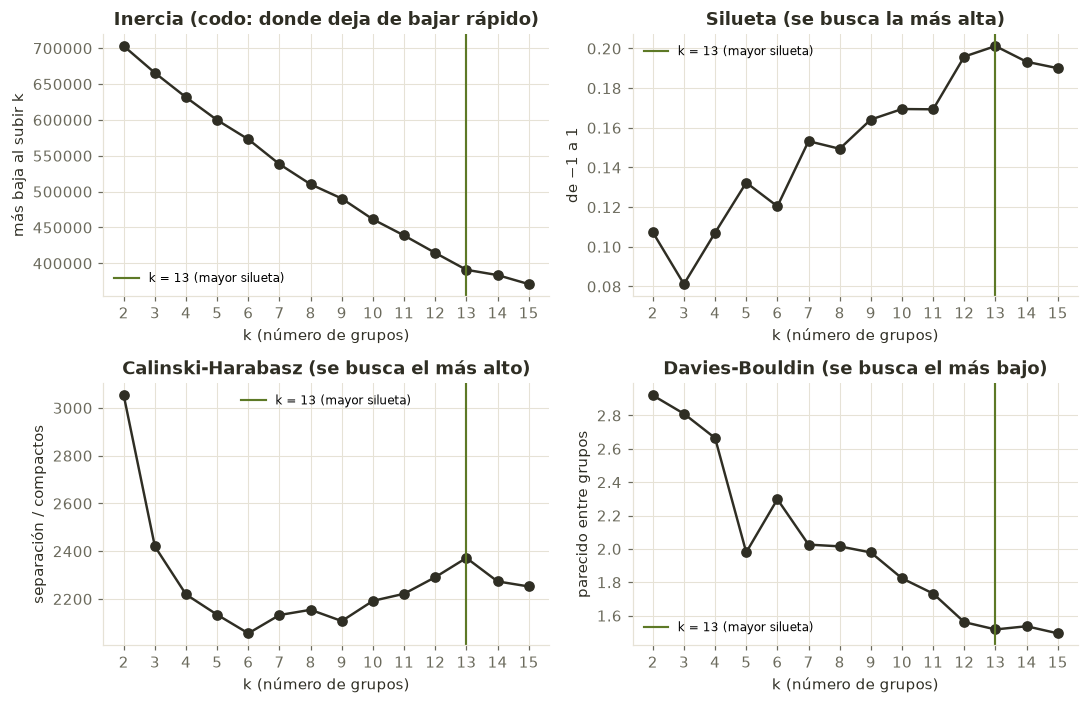

,inercia,silueta,calinski_harabasz,davies_bouldin
k,,,,
2,703014.305,0.107,3052.886,2.921
3,665652.693,0.081,2420.159,2.810
4,631540.476,0.107,2218.958,2.665
5,599738.072,0.132,2134.119,1.980
6,572957.243,0.120,2056.185,2.298
7,538284.187,0.153,2132.884,2.026
8,510226.664,0.149,2154.820,2.015
9,490351.476,0.164,2107.683,1.979
10,461352.077,0.169,2192.250,1.824


k con mayor silueta: 13  |  silueta = 0.201
k con mayor Calinski-Harabasz: 2
k con menor Davies-Bouldin: 15


In [6]:
# Regla declarada antes de mirar los nombres de las recetas: gana la silueta más alta.
k_silueta = int(metricas["silueta"].idxmax())

fig, ejes = plt.subplots(2, 2, figsize=(10, 6.5))
paneles = [
    ("inercia", "Inercia (codo: donde deja de bajar rápido)", "más baja al subir k"),
    ("silueta", "Silueta (se busca la más alta)", "de −1 a 1"),
    ("calinski_harabasz", "Calinski-Harabasz (se busca el más alto)", "separación / compactos"),
    ("davies_bouldin", "Davies-Bouldin (se busca el más bajo)", "parecido entre grupos"),
]
for eje, (columna, titulo, ayuda) in zip(ejes.ravel(), paneles):
    eje.plot(metricas.index, metricas[columna], color=INK, marker="o", linewidth=1.6)
    eje.axvline(k_silueta, color=OLIVE, linewidth=1.4, label=f"k = {k_silueta} (mayor silueta)")
    eje.set_title(titulo)
    eje.set_xlabel("k (número de grupos)")
    eje.set_ylabel(ayuda)
    eje.set_xticks(list(metricas.index))
    eje.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()
display(metricas.round(3))
print(f"k con mayor silueta: {k_silueta}  |  silueta = {metricas.loc[k_silueta, 'silueta']:.3f}")
print(f"k con mayor Calinski-Harabasz: {int(metricas['calinski_harabasz'].idxmax())}")
print(f"k con menor Davies-Bouldin: {int(metricas['davies_bouldin'].idxmin())}")
if k_silueta in (K_MIN, K_MAX):
    print("Ojo: la silueta máxima está en un extremo del rango. Amplía K_MIN/K_MAX y vuelve a correr;")
    print("un extremo no es un pico, solo el último número que se probó.")


## 6. Modelo final

Por defecto se usa el `k` de mayor silueta. Para probar otro (por ejemplo el del codo), escribe el número en `K_FORZADO` y vuelve a correr esta celda y las siguientes.

El modelo se ajusta otra vez con la misma semilla y los mismos 10 arranques. El resultado es el mismo que en la búsqueda de arriba.


In [7]:
# None = el k de mayor silueta. Un entero (entre K_MIN y K_MAX) obliga ese k.
K_FORZADO = None

K = k_silueta if K_FORZADO is None else int(K_FORZADO)
assert K_MIN <= K <= K_MAX, f"K tiene que estar entre {K_MIN} y {K_MAX}"

modelo_final = KMeans(n_clusters=K, n_init=N_INIT, random_state=RANDOM_STATE)
etiquetas = modelo_final.fit_predict(X)

# La etiqueta se pega a una copia. df no se modifica y el CSV no se reescribe.
recetas = df.copy()
recetas["cluster"] = etiquetas

tamaños = recetas["cluster"].value_counts().sort_index()
resumen_tamaños = pd.DataFrame({
    "recetas": tamaños,
    "porcentaje": (tamaños / len(recetas) * 100).round(1),
})
print(f"k usado: {K} ({'silueta' if K_FORZADO is None else 'forzado a mano'})")
print(f"Inercia del modelo final: {modelo_final.inertia_:,.0f}")
display(resumen_tamaños)


k usado: 13 (silueta)
Inercia del modelo final: 390,959


,recetas,porcentaje
cluster,,
0,1369,4.8
1,1527,5.3
2,2504,8.7
3,3262,11.3
4,3078,10.7
5,1171,4.1
6,5586,19.4
7,413,1.4
8,1813,6.3


La silueta de cada grupo, en la misma muestra de 4,000. Una barra larga y a la derecha quiere decir que las recetas de ese grupo están más cerca de su centro que del grupo de al lado. Una barra que cruza a la izquierda (valor negativo) son recetas que quedaron mal ubicadas.

El promedio de estas barras es la silueta del `k` elegido. No es todavía una lectura de qué se cocina en cada grupo.


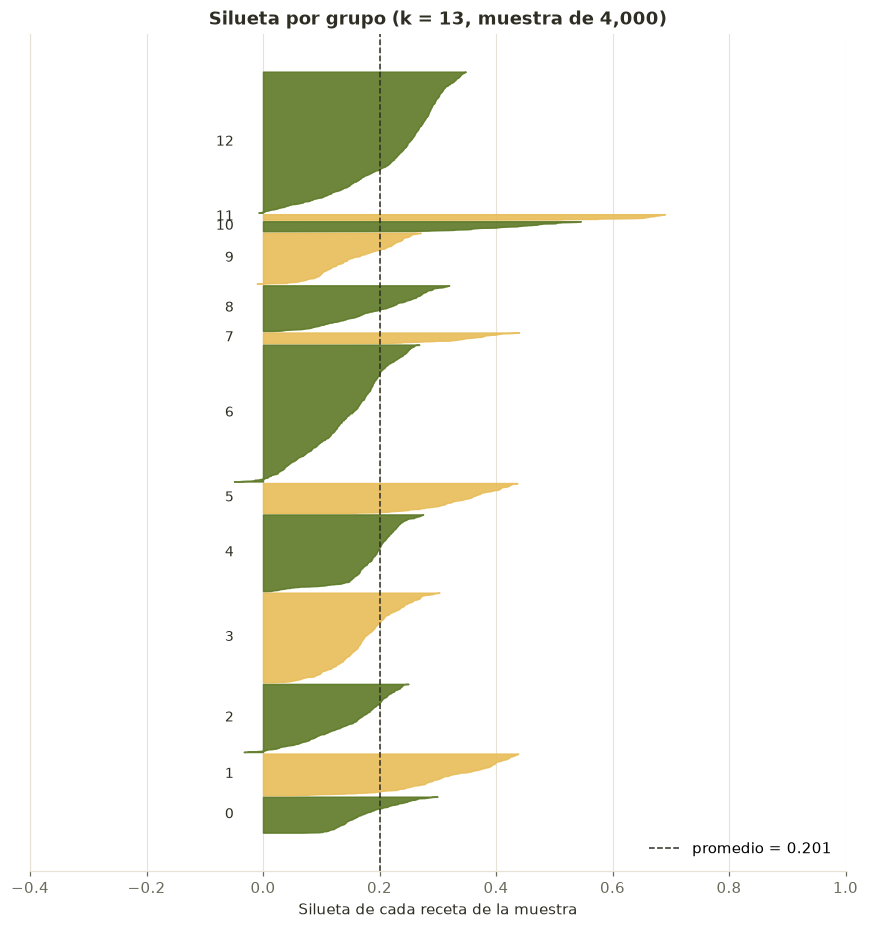

In [8]:
indices = indices_de_muestra(etiquetas, SILHOUETTE_SAMPLE, RANDOM_STATE)
siluetas = silhouette_samples(X[indices], etiquetas[indices])
etiquetas_muestra = etiquetas[indices]

fig, eje = plt.subplots(figsize=(8, 0.55 * K + 1.4))
y_inferior = 0
for grupo in range(K):
    valores = np.sort(siluetas[etiquetas_muestra == grupo])
    y_superior = y_inferior + len(valores)
    eje.fill_betweenx(
        np.arange(y_inferior, y_superior),
        0,
        valores,
        color=OLIVE if grupo % 2 == 0 else MUSTARD,
        alpha=0.9,
    )
    eje.text(-0.05, (y_inferior + y_superior) / 2, str(grupo), va="center", ha="right", color=INK, fontsize=9)
    y_inferior = y_superior + 8

eje.axvline(siluetas.mean(), color=INK, linestyle="--", linewidth=1, label=f"promedio = {siluetas.mean():.3f}")
eje.set_yticks([])
eje.set_xlim(-0.4, 1)
eje.set_xlabel("Silueta de cada receta de la muestra")
eje.set_title(f"Silueta por grupo (k = {K}, muestra de {SILHOUETTE_SAMPLE:,})")
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()


## 7. Material para la interpretación

Los centros de K-Means viven en la escala del paso 4 (logaritmo y desviaciones). Para leerlos se vuelve a las columnas originales y se resume cada grupo:

* **Tamaño** (ya salió en la sección 6).
* **Mediana y promedio** de ingredientes, pasos y minutos. La mediana se mueve menos si unas pocas recetas tienen tiempos enormes.
* **Proporción** de cada etiqueta, técnica y dificultad. Un 0.70 en `tag_postre` quiere decir que el 70 % de ese grupo tiene la etiqueta Postre.
* **Diferencia contra el catálogo completo.** Sirve para ver qué columna se aleja del promedio de todas las recetas. No le pone nombre al grupo.
* **Cinco recetas más cercanas al centro.** Representan el grupo mejor que cinco recetas al azar, que pueden ser las raras.

Nada de esto dice todavía si el corte es útil. Eso va en la sección 8.


Ingredientes, pasos y minutos dentro de cada grupo


n_ingredients          n_steps          time_filled_min         
              mediana promedio mediana promedio         mediana promedio
cluster                                                                 
0                10.0     10.1     8.0      9.3            40.0     46.9
1                 8.0      7.9    11.0     11.5            30.0     43.4
2                 9.0      9.4     9.0     10.2            44.0     51.6
3                 8.0      8.4     7.0      7.6            40.0     38.3
4                 9.0      9.8    10.0     10.9            30.0     42.0
5                 5.0      5.7     4.0      4.9            15.0     23.0
6                 8.0      8.1     9.0     10.2            30.0     38.1
7                 9.0      9.9     9.0     11.4            45.0     73.1
8                10.0     11.0     9.0     10.1            45.0     52.1
9                11.0     11.1    10.0     11.2            45.0     55.9
10                9.0      9.8     8.0      9.1            30.0     55.5
11               11.0     11.0    10.0     10.3            45.0     63.4
12                7.0      7.6    10.0     11.3            45.0     67.9

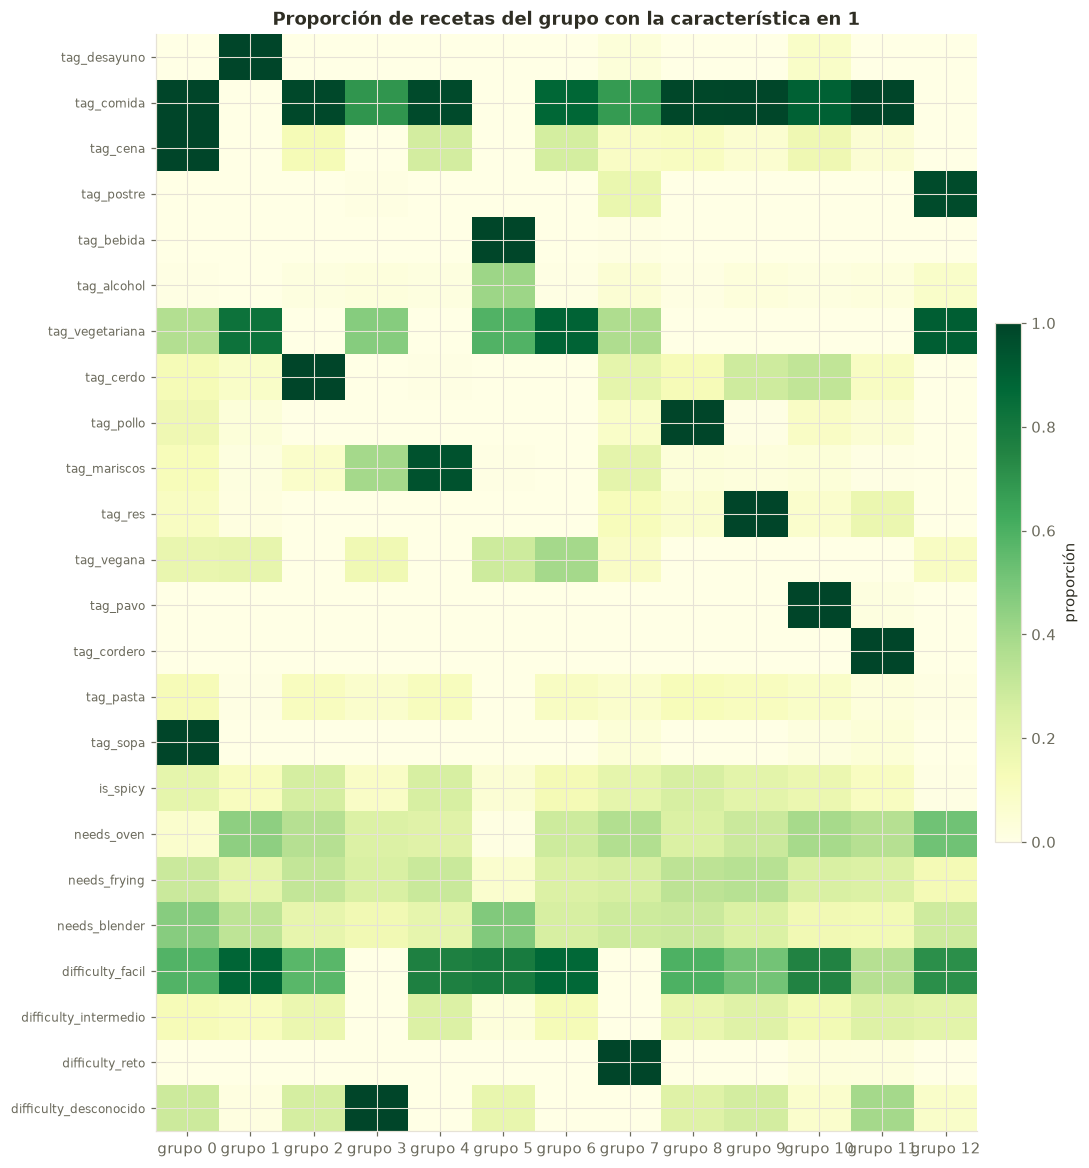

In [9]:
columnas_binarias = TAG_COLS + FLAG_COLS + [f"difficulty_{nivel}" for nivel in DIFFICULTY_LEVELS]

perfil_conteos = (
    recetas.groupby("cluster")[COUNT_COLS]
    .agg(["median", "mean"])
    .rename(columns={"median": "mediana", "mean": "promedio"})
    .round(1)
)
# Las columnas difficulty_* viven en X_original, no en el CSV.
# Se pega el grupo para poder promediarlas. Un 0.70 significa "70 % del grupo".
con_grupo = X_original.copy()
con_grupo["cluster"] = etiquetas
proporciones = con_grupo.groupby("cluster")[columnas_binarias].mean()
# La misma proporción en todo el catálogo, para restarla.
proporcion_global = X_original[columnas_binarias].mean()

print("Ingredientes, pasos y minutos dentro de cada grupo")
display(perfil_conteos)

fig, eje = plt.subplots(figsize=(10, 0.38 * len(columnas_binarias) + 1.6))
imagen = eje.imshow(proporciones.T.to_numpy(), aspect="auto", cmap="YlGn", vmin=0, vmax=1)
eje.set_xticks(range(K))
eje.set_xticklabels([f"grupo {g}" for g in range(K)])
eje.set_yticks(range(len(columnas_binarias)))
eje.set_yticklabels(columnas_binarias, fontsize=8)
eje.set_title("Proporción de recetas del grupo con la característica en 1")
fig.colorbar(imagen, ax=eje, fraction=0.03, pad=0.02, label="proporción")
fig.tight_layout()
plt.show()


In [10]:
# Para cada grupo, las 8 columnas 0/1 que más se alejan del promedio de todo el catálogo.
rasgos = []
for grupo in range(K):
    diferencia = proporciones.loc[grupo] - proporcion_global
    destacadas = diferencia.abs().sort_values(ascending=False).head(8).index
    tabla = pd.DataFrame({
        "cluster": grupo,
        "columna": destacadas,
        "en_el_grupo": proporciones.loc[grupo, destacadas].to_numpy(),
        "en_todo_el_catalogo": proporcion_global[destacadas].to_numpy(),
        "diferencia": diferencia[destacadas].to_numpy(),
    })
    rasgos.append(tabla)

rasgos = pd.concat(rasgos, ignore_index=True)
rasgos[["en_el_grupo", "en_todo_el_catalogo", "diferencia"]] = rasgos[
    ["en_el_grupo", "en_todo_el_catalogo", "diferencia"]
].round(3)
display(rasgos)


,cluster,columna,en_el_grupo,en_todo_el_catalogo,diferencia
0,0,tag_sopa,1.000,0.049,0.951
1,0,tag_cena,1.000,0.153,0.847
2,0,tag_comida,1.000,0.649,0.351
3,0,needs_oven,0.066,0.309,-0.242
4,0,needs_blender,0.465,0.259,0.206
...,...,...,...,...,...
99,12,needs_oven,0.519,0.309,0.210
100,12,tag_mariscos,0.000,0.167,-0.167
101,12,tag_cena,0.000,0.153,-0.153
102,12,is_spicy,0.007,0.142,-0.135


In [11]:
# Distancia de cada receta a cada centro, en la escala en la que se ajustó K-Means.
distancia_a_centros = modelo_final.transform(X)

cercanas = []
for grupo in range(K):
    del_grupo = np.flatnonzero(etiquetas == grupo)
    orden = del_grupo[np.argsort(distancia_a_centros[del_grupo, grupo])]
    toma = recetas.iloc[orden[:5]][["name", "tags", "n_ingredients", "n_steps", "time_filled_min", "difficulty"]].copy()
    toma.insert(0, "cluster", grupo)
    toma.insert(1, "distancia_al_centro", distancia_a_centros[orden[:5], grupo].round(3))
    cercanas.append(toma)

cercanas = pd.concat(cercanas, ignore_index=True)
display(cercanas)


,cluster,distancia_al_centro,name,tags,n_ingredients,n_steps,time_filled_min,difficulty
0,0,2.286,Sopa de Cebolla con Pan y Queso,Comida | Cena | Sopa,9,8,30.0,facil
1,0,2.292,Sopa Japonesa de Champinones,Comida | Cena | Sopa,9,9,30.0,facil
2,0,2.306,Crema de Queso,Comida | Cena | Sopa,11,8,30.0,facil
3,0,2.328,Crema de Zanahoria Almendrada,Comida | Cena | Sopa,10,8,40.0,facil
4,0,2.328,Sopa de Alcachofa,Comida | Cena | Sopa,10,8,40.0,facil
...,...,...,...,...,...,...,...,...
60,12,1.618,Flan Napolitano de Queso Crema,Postre | Vegetariana,7,10,45.0,facil
61,12,1.618,Budin de Manzana con Harina Integral,Postre | Vegetariana,7,10,45.0,facil
62,12,1.623,Manzanas Asadas con Almendras,Postre | Vegetariana,7,9,45.0,facil
63,12,1.623,Galletas para Decorar,Postre | Vegetariana,7,9,45.0,facil


## 8. Interpretación

Las cifras de tamaño, mediana de ingredientes, pasos y minutos salen de las tablas de la sección 7. Las proporciones de etiquetas y técnicas se leyeron del mapa de calor, así que son aproximadas.

### 8.1 Qué `k` se eligió y qué tan firme es

| Métrica | Mejor `k` | Valor |
| --- | --- | --- |
| Silueta (regla de este notebook) | 13 | 0.201 |
| Calinski-Harabasz | 2 | 3,053 |
| Davies-Bouldin | 15 (extremo del rango) | 1.494 |

* Las tres métricas **no coinciden**. El `k = 13` sale de la regla declarada (mayor silueta), no de un acuerdo entre métricas.
* La silueta de 0.201 es baja: los grupos se distinguen, pero no están bien separados. Entre `k = 12` y `k = 15` la silueta es casi igual (0.196, 0.201, 0.193, 0.190). Con una muestra de 4,000 recetas esa diferencia es pequeña, así que el 13 es defendible, no único.
* Davies-Bouldin sigue mejorando hasta el borde del rango. Ahí no hay un pico, solo el último `k` probado.

### 8.2 Los grupos

| Grupo | Recetas | % | Qué lo define | Nombre propuesto |
| --- | --- | --- | --- | --- |
| 0 | 1,369 | 4.8 | Sopa, cena y comida en el 100 %. Casi sin horno. Las más cercanas al centro son sopas y cremas fáciles | **Sopas y cremas** |
| 1 | 1,527 | 5.3 | Desayuno en el 100 %. Mayoría vegetariana y fácil. Mediana de 11 pasos y 30 min | **Desayunos** |
| 2 | 2,504 | 8.7 | Comida y cerdo en el 100 % | **Platos de cerdo** |
| 3 | 3,262 | 11.3 | Dificultad desconocida en el 100 %. El resto del perfil es mezclado (comida, algo vegetariano, algo de mariscos) | **Sin dificultad registrada** |
| 4 | 3,078 | 10.7 | Comida y mariscos en el 100 %. Casi todo fácil. Mediana de 30 min | **Pescados y mariscos** |
| 5 | 1,171 | 4.1 | Bebida en el 100 %. La más chica de todas: mediana de 5 ingredientes, 4 pasos y 15 min. Licuadora y algo de alcohol | **Bebidas y cocteles** |
| 6 | 5,586 | 19.4 | Comida, mayoría vegetariana, parte vegana, casi toda fácil. Sin una proteína definida | **Comidas vegetarianas del diario** |
| 7 | 413 | 1.4 | Dificultad "reto" en el 100 %. Promedio de 73 min contra mediana de 45: pocas recetas muy largas | **Recetas de reto** |
| 8 | 1,813 | 6.3 | Comida y pollo en el 100 % | **Platos de pollo** |
| 9 | 2,144 | 7.4 | Comida y res en el 100 %. Mediana de 11 ingredientes, la más alta junto con el grupo 11 | **Platos de res** |
| 10 | 364 | 1.3 | Pavo en el 100 % | **Platos de pavo** |
| 11 | 165 | 0.6 | Cordero en el 100 % | **Platos de cordero** |
| 12 | 5,402 | 18.8 | Postre en el 100 %, casi todo vegetariano, horno en cerca de la mitad. Las más cercanas al centro son flan, budín, galletas y natillas | **Postres** |

Las recetas cercanas al centro que se pudieron revisar (grupos 0 y 12) cuentan la misma historia que las proporciones. Los nombres son una propuesta: el número de cada grupo sigue sin tener orden ni valor.

### 8.3 Qué dice el agrupamiento

1. **La mayoría de los grupos coincide con una etiqueta de la app.** Hay 16 columnas `tag_*` entre las 27 que entran, y las de proteína casi no se mezclan entre sí. Por eso K-Means las separa sin esfuerzo: cerdo, pollo, res, pavo, cordero, mariscos, sopa, desayuno, bebida y postre salen cada una como grupo propio. El resultado confirma que las etiquetas son coherentes, pero no descubre una estructura que las etiquetas no mostraran ya.
2. **Los grupos 3 y 7 vienen de la dificultad, no del plato.** El 3 junta las recetas sin dificultad (el 21 % del catálogo) y el 7 las marcadas como "reto". Son grupos reales para el algoritmo, pero no describen una forma distinta de cocinar. El 3 en particular refleja un dato faltante.
3. **El grupo 6 es el más parecido a "el resto".** Es grande (19 %), mezclado, sin una proteína ni un tipo de plato claro, y su silueta es de las más bajas, con algunas recetas ya negativas. Los grupos 1, 5, 7, 10 y 11 son los mejor separados en la gráfica de silueta.
4. **Los minutos y el tamaño separan poco.** Casi todos los grupos tienen entre 30 y 45 min de mediana y entre 7 y 11 ingredientes. Solo el grupo 5 se distingue claramente por ser corto y pequeño. Varios grupos coinciden en una mediana de 45 min, lo que apunta a que muchas recetas traen el tiempo estimado por el notebook 02; habría que confirmarlo contra el CSV.
5. **Los grupos chicos (10 y 11) son proteínas poco frecuentes**, no ruido. Con 364 y 165 recetas siguen siendo reconocibles y con buena silueta.

### 8.4 Límites y qué probar después

* **Ampliar el rango de `k`** a 20 o más para ver si Davies-Bouldin llega a un pico y si se parten grupos grandes (por ejemplo, mariscos en pescado y camarón).
* **Repetir sin las columnas de dificultad** y comparar. Si los grupos 3 y 7 desaparecen y el resto se mantiene, la estructura de platos es estable.
* **Fijar otro valor en `K_FORZADO`** (por ejemplo 12 o 14) y revisar si los nombres de 8.2 siguen siendo válidos.
* **Revisar la tabla de rasgos completa** (`rasgos`) y las cinco recetas cercanas de cada grupo, que en la versión guardada del notebook quedaron truncadas en pantalla. Las proporciones de 8.2 se pueden confirmar ahí.
* Esto es una descripción del catálogo, no un recomendador. Para sugerir recetas parecidas siguen siendo los notebooks 03 a 05.
